
# Exploratory Data Analysis (EDA)
## Mối tương quan giữa `recovery_days` và các feature

Notebook này trực quan hóa mối quan hệ giữa **số ngày hồi phục (recovery_days)** và các đặc trưng trong bộ dữ liệu thiên tai.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)


In [2]:
df = pd.read_csv("../data/global_disaster_response_2018_2024.csv")
df.head()

,date,country,disaster_type,severity_index,casualties,economic_loss_usd,response_time_hours,aid_amount_usd,response_efficiency_score,recovery_days,latitude,longitude
0,31/1/2021,Brazil,Earthquake,5.99,111,7934365.71,15.62,271603.79,83.21,67,-30.613,-122.557
1,23/12/2018,Brazil,Extreme Heat,6.53,100,8307648.99,5.03,265873.81,96.18,55,10.859,-159.194
2,10/8/2020,India,Hurricane,1.55,22,765136.99,32.54,49356.49,60.40,22,0.643,-160.978
3,15/9/2022,Indonesia,Extreme Heat,4.55,94,1308251.31,7.83,237512.88,86.41,47,-33.547,30.350
4,28/9/2022,United States,Wildfire,3.80,64,2655864.36,21.90,188910.69,72.81,42,-19.170,-117.137



## Thống kê mô tả nhanh


In [7]:

df.describe()


,severity_index,casualties,economic_loss_usd,response_time_hours,aid_amount_usd,response_efficiency_score,recovery_days,latitude,longitude
count,50000.000000,50000.000000,5.000000e+04,50000.000000,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.000000
mean,5.015769,100.591140,5.068593e+06,12.183027,2.500003e+05,87.574025,49.682560,0.231205,0.089889
std,1.942843,65.052064,3.268541e+06,9.259081,1.432275e+05,10.188961,20.098944,34.759662,98.380208
min,1.000000,0.000000,5.273900e+02,1.000000,1.660000e+01,29.750000,2.000000,-59.994000,-169.998000
25%,3.660000,51.000000,2.585513e+06,6.270000,1.429663e+05,83.060000,36.000000,-29.848250,-85.551750
50%,4.990000,91.000000,4.548351e+06,10.510000,2.305365e+05,89.180000,49.000000,0.267500,0.390500
75%,6.340000,138.000000,6.950615e+06,15.450000,3.352259e+05,94.700000,63.000000,30.488250,85.665000
max,10.000000,524.000000,2.445624e+07,63.100000,1.126465e+06,100.000000,112.000000,59.997000,169.999000



## 1. Tương quan Pearson giữa recovery_days và các feature số


In [9]:

numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

recovery_corr = (
    corr["recovery_days"]
    .drop("recovery_days")
    .sort_values(ascending=False)
)

recovery_corr


severity_index               0.968534
aid_amount_usd               0.649868
economic_loss_usd            0.581612
casualties                   0.581541
response_efficiency_score    0.579997
longitude                    0.004028
latitude                     0.003866
response_time_hours         -0.654478
Name: recovery_days, dtype: float64

C:\Users\khoa\AppData\Local\Temp\ipykernel_9372\1482482720.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


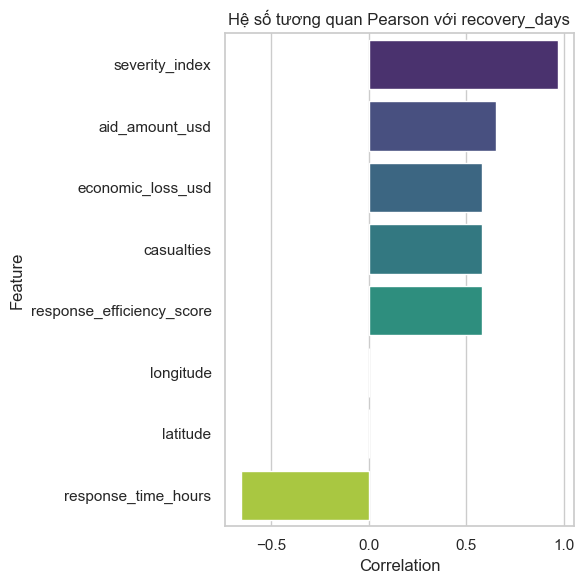

In [10]:

plt.figure(figsize=(6,6))
sns.barplot(
    x=recovery_corr.values,
    y=recovery_corr.index,
    palette="viridis"
)
plt.title("Hệ số tương quan Pearson với recovery_days")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


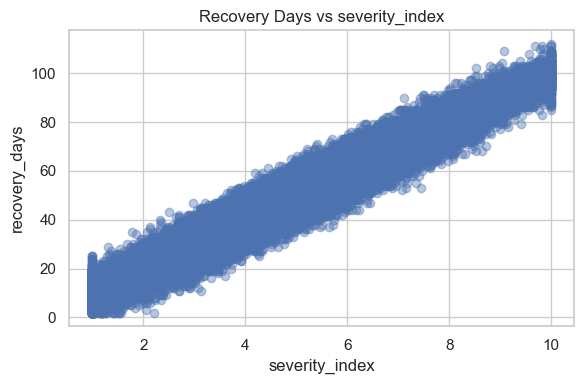

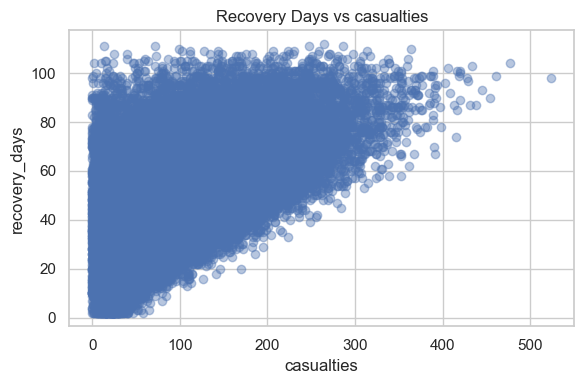

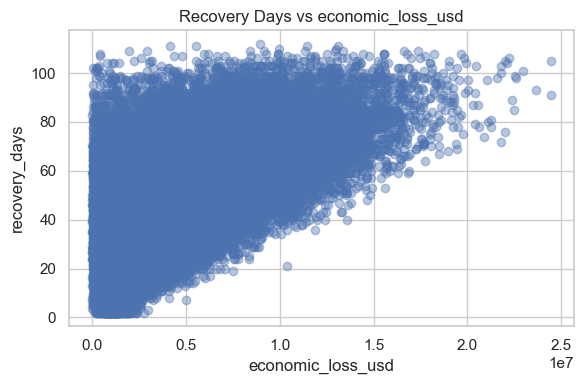

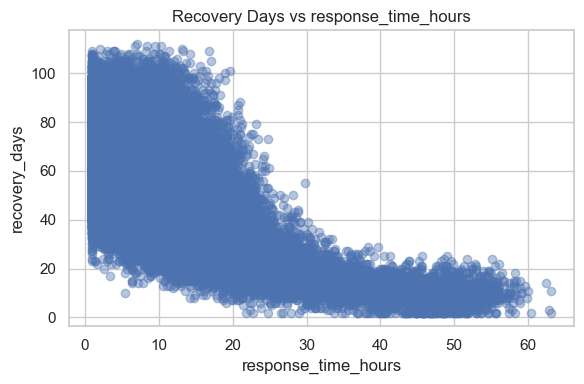

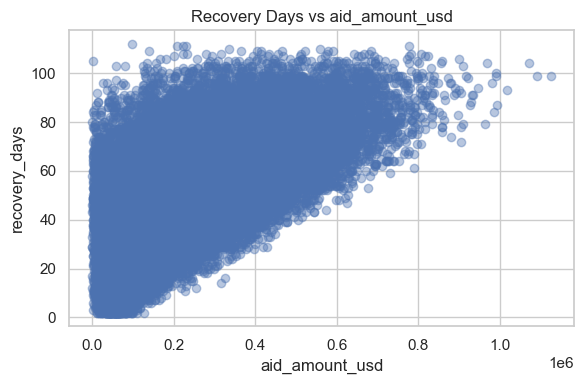

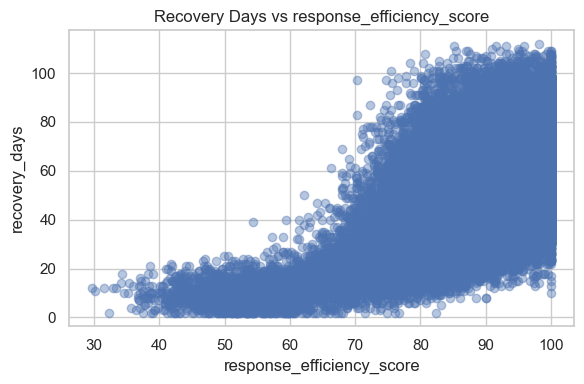

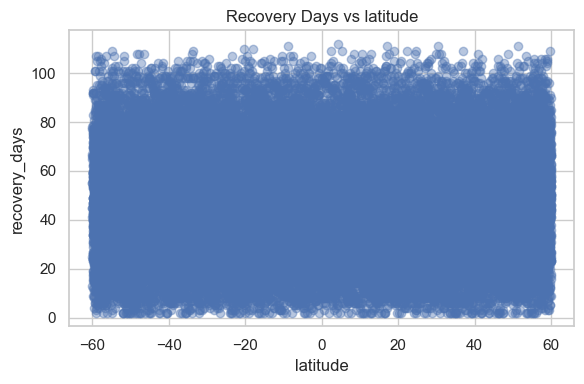

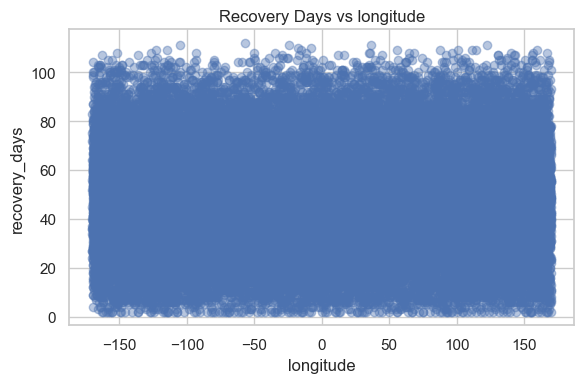

In [11]:
import matplotlib.pyplot as plt
import numpy as np

target = "recovery_days"

numeric_features = (
    df.select_dtypes(include=[np.number])
      .columns
      .drop(target)
)

for col in numeric_features:
    plt.figure(figsize=(6,4))
    plt.scatter(df[col], df[target], alpha=0.4)
    plt.xlabel(col)
    plt.ylabel("recovery_days")
    plt.title(f"Recovery Days vs {col}")
    plt.tight_layout()
    plt.show()


- mức độ thảm họa

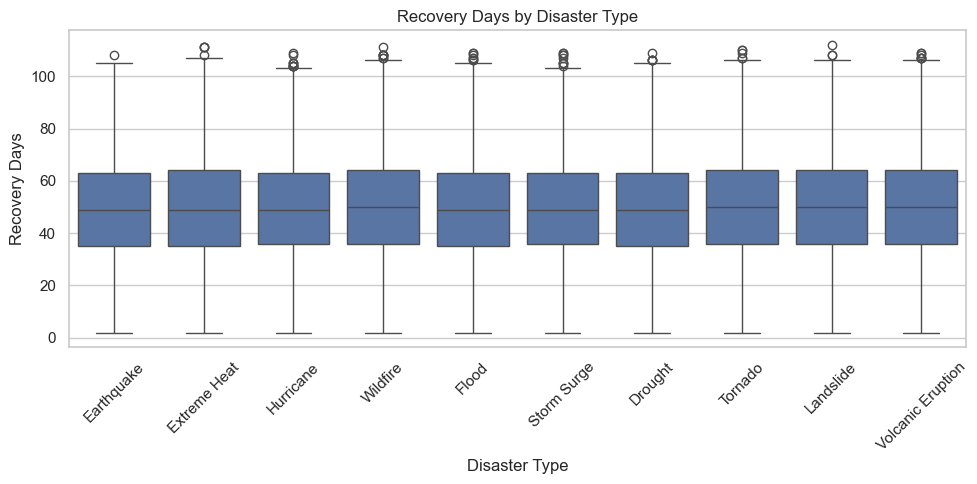

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.boxplot(
    data=df,
    x="disaster_type",
    y="recovery_days"
)
plt.xticks(rotation=45)
plt.title("Recovery Days by Disaster Type")
plt.xlabel("Disaster Type")
plt.ylabel("Recovery Days")
plt.tight_layout()
plt.show()


C:\Users\khoa\AppData\Local\Temp\ipykernel_9372\296546958.py:2: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


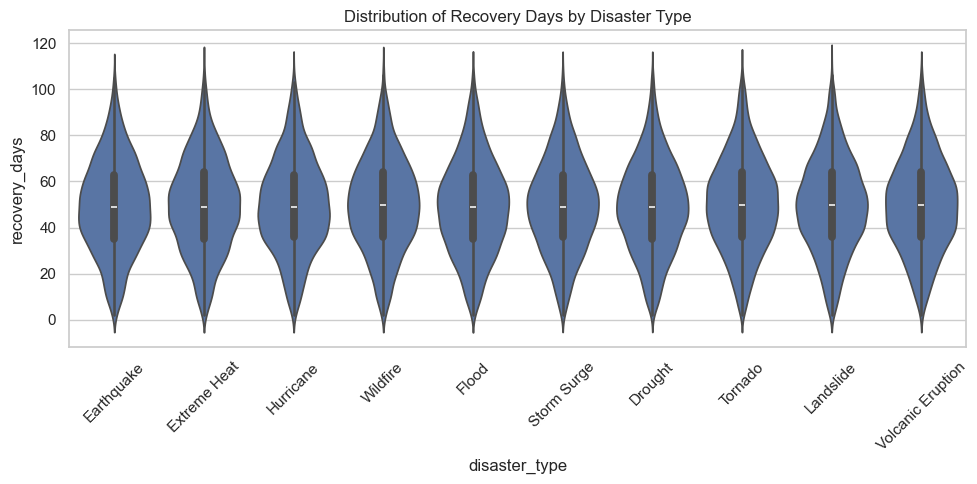

In [13]:
plt.figure(figsize=(10,5))
sns.violinplot(
    data=df,
    x="disaster_type",
    y="recovery_days",
    scale="width"
)
plt.xticks(rotation=45)
plt.title("Distribution of Recovery Days by Disaster Type")
plt.tight_layout()
plt.show()



## 2. Scatter plot: recovery_days vs từng feature chính


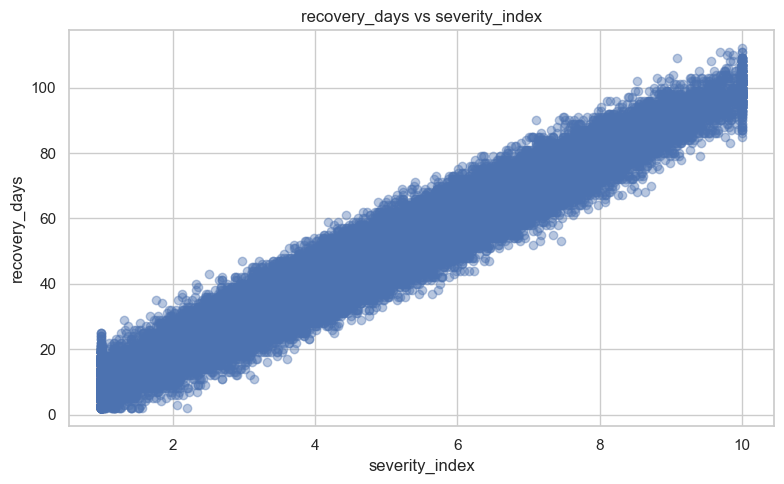

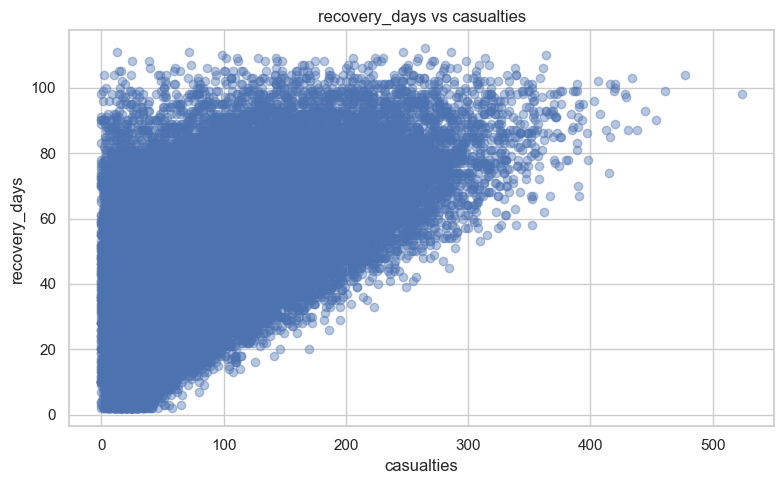

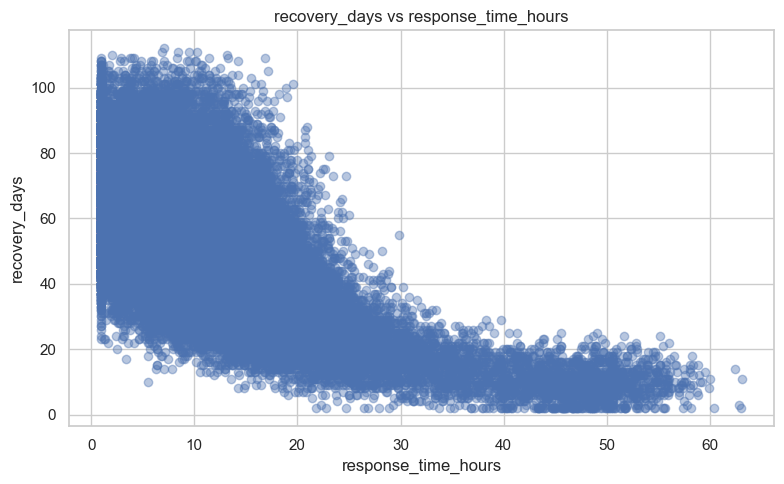

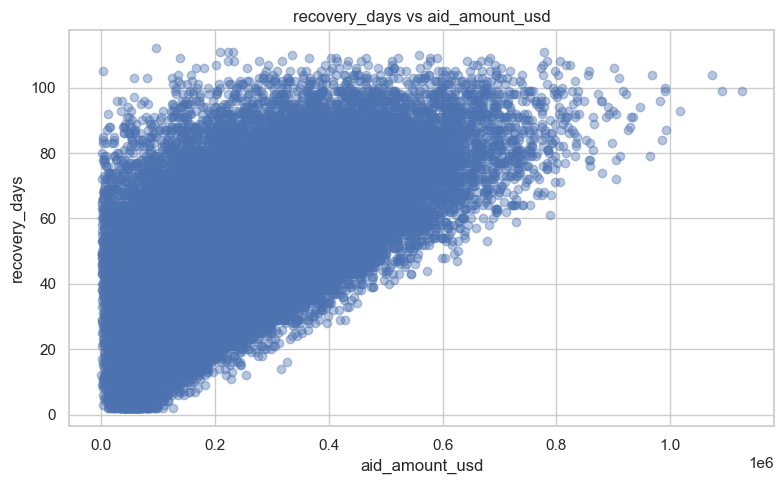

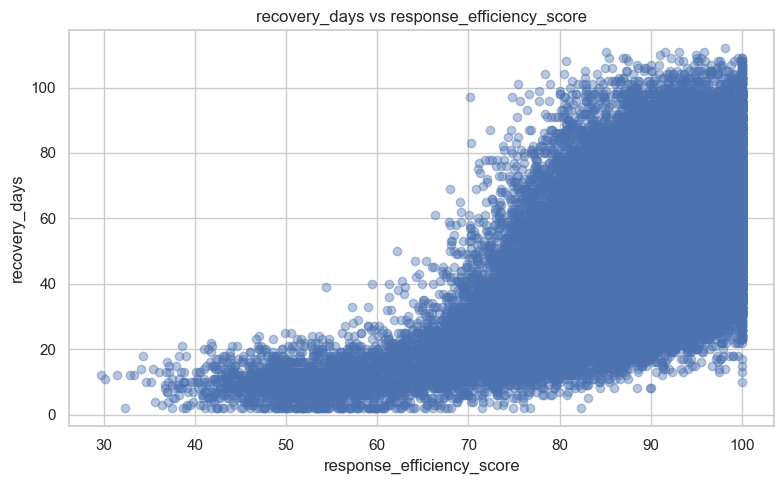

In [3]:

key_features = [
    "severity_index",
    "casualties",
    "response_time_hours",
    "aid_amount_usd",
    "response_efficiency_score"
]

for col in key_features:
    if col in df.columns:
        plt.figure()
        plt.scatter(df[col], df["recovery_days"], alpha=0.4)
        plt.xlabel(col)
        plt.ylabel("recovery_days")
        plt.title(f"recovery_days vs {col}")
        plt.tight_layout()
        plt.show()



## 3. Biểu đồ phân phối recovery_days


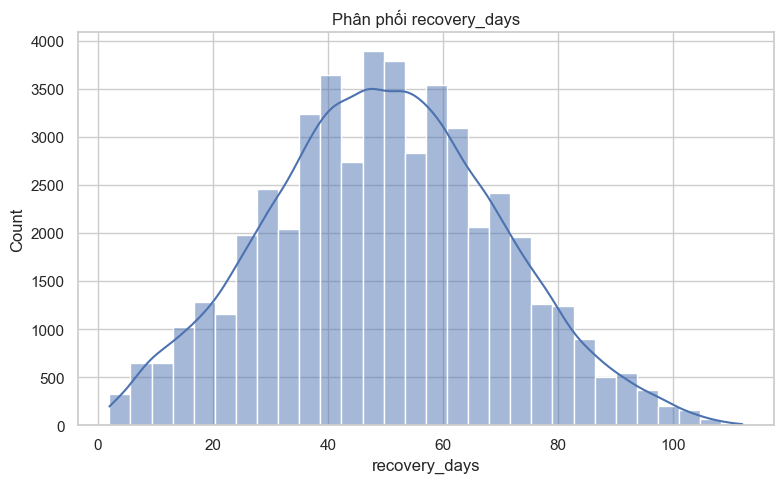

In [4]:

plt.figure()
sns.histplot(df["recovery_days"], bins=30, kde=True)
plt.title("Phân phối recovery_days")
plt.xlabel("recovery_days")
plt.ylabel("Count")
plt.tight_layout()
plt.show()



## 4. Nhận xét sơ bộ

- `recovery_days` có tương quan mạnh hơn với **severity_index** và **response_time_hours**
- Các feature như `aid_amount_usd` thường phân tán mạnh, quan hệ phi tuyến
- Dữ liệu có nhiễu cao → phù hợp với ensemble models (RF, HGB, Stacking)
